In [1]:
import gdsfactory as gf
from ihp import PDK
from ihp.cells.capacitors import rfcmim
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

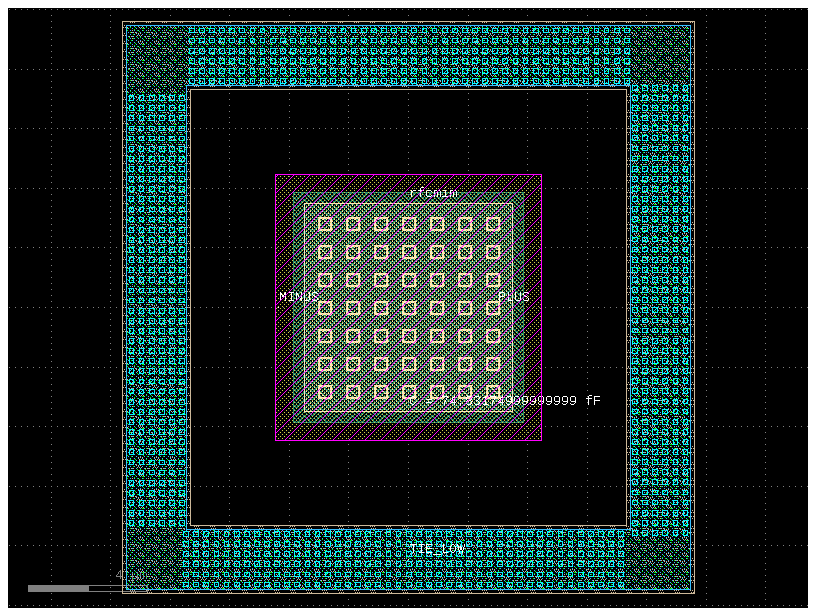

In [45]:
c = rfcmim(width=7.0, length=7.0)

cc = gf.Component()

for layer in c.layers:
    layer_number, datatype = layer
    if datatype != 0:
        continue
    layer_comp = c.extract(layers=[layer])
    cc.add_ref(layer_comp)

cc.add_ports(c.ports)
cc.flatten()
cc

In [ ]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-rfcmim")
sim.set_geometry(cc)

sim.set_stack(yaml_path=yaml_file)

sim.add_port("PLUS",layer="metal1", geometry="inplane",length=0.5,excited=True)
sim.add_port("MINUS",layer="metal5",geometry="inplane",length=0.5,excited=False)

sim.add_port("TIE_LOW",layer="metal1",geometry="inplane",length=0.5,excited=False)
sim.set_driven(fmin=1e9, fmax=20e9, num_points=21)

print(sim.validate_config())

Validation: PASSED
Warnings:
  - No ports configured. Call add_port() or add_cpw_port().


In [ ]:
sim.plot_mesh(show_groups=["metal","P"],interactive=True)